In [41]:
/env/bin/python -m pip install pymannkendall 

env: /bin/python(-m,=pip, install, pymannkendall)


In [42]:
pip install pymannkendall


Note: you may need to restart the kernel to use updated packages.


In [43]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime
import geopandas as gpd

from pymannkendall.pymannkendall import (
    __preprocessing,
    __missing_values_analysis,
    __mk_score,
    __variance_s,
    __z_score,
    __p_value,
    sens_slope,
)

In [51]:
csv_path = "178.csv"                    #ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
df = pd.read_csv(csv_path)

# Convert date and sort
df = df.reset_index()
df["TIME"] = pd.to_datetime(df["TIME"])          # convert to datetime
df["TIME"] = df.index           

pv = df.PV.resample('MS').mean().interpolate(method='cubic')    #ACTION: Change the component you are analysing

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

Index(['index', 'BS', 'NPV', 'PV', 'WET', 'WATER'], dtype='object')


In [49]:
print(df.head())
print(df.columns)


                         index        BS       NPV        PV       WET  WATER
TIME                                                                         
1987-09-18 23:17:37.500      0  0.053016  0.396283  0.535489  0.002229    0.0
1987-09-25 23:23:58.000      1  0.043028  0.403658  0.540190  0.000686    0.0
1987-10-04 23:17:58.500      2  0.076398  0.300965  0.495443  0.114007    0.0
1987-11-21 23:18:53.500      3  0.055615  0.400228  0.530338  0.000000    0.0
1987-11-28 23:25:11.000      4  0.119470  0.379033  0.486789  0.000000    0.0
Index(['index', 'BS', 'NPV', 'PV', 'WET', 'WATER'], dtype='object')


In [45]:
def generate_low_quality_data_periods(df):
    """
    This function generates low quality data periods, including the SLC off period
    (https://www.usgs.gov/faqs/what-landsat-7-etm-slc-data)
    and periods with an observation density of less than four observations within a
    twelve month (365 days) period.
    Off value is 100 where there is low data quality and 0 for good data.
    """
    df = df.copy()
    df.loc[:, "off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100

    return df

df = df.reset_index(drop=True)
df["TIME"] = pd.to_datetime(df["TIME"])

# Generate low-quality data column
df = generate_low_quality_data_periods(df)

# Extract the variable
pv = df.set_index("TIME")["PV"].astype(float)                 #ACTION: Change the component you are analysing

# Identify low-quality ranges based on off_value == 100
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    # Group consecutive low-quality periods
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Filter out large gaps for decomposition
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose the time series
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

# Plot
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="PV", color="black")                #ACTION: Change the component you are analysing
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

# Shade low-quality data periods
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="red", hatch="///", alpha=0.4)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

KeyError: 'TIME'

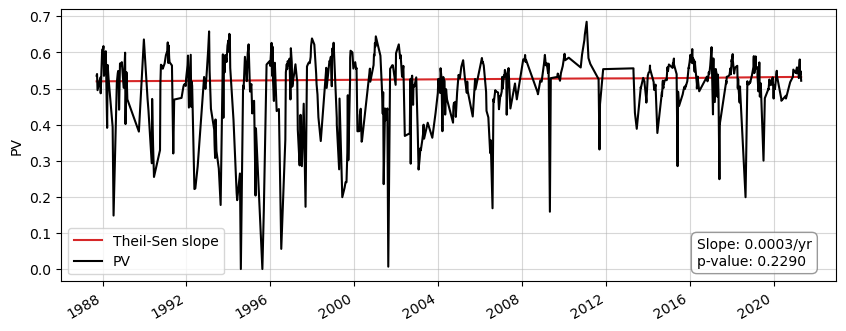

In [17]:
def mk_with_slopes(y, alpha = 0.05):
    """
    This function checks the Mann-Kendall (MK) test (Mann 1945, Kendall 1975, Gilbert 1987).
    This was modified from the "pymannkendall" library to return fewer statistics which makes
    it a little more robust.
    
    Input:
        x: a vector (list, numpy array or pandas series) data
        alpha: significance level (0.05 default)
    Output:
        p: p-value of the significance test
        slope: Theil-Sen estimator/slope
        intercept: intercept of Kendall-Theil Robust Line
        
    """
    res = namedtuple('Mann_Kendall_Test', ['p','slope','intercept'])
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method = 'skip')
    
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    slope, intercept = sens_slope(y)

    return res(p, slope, intercept)

# slope, intercept, lo_slope, up_slope = theilslopes(y, x, 0.95)
p, slope, intercept = mk_with_slopes(pv)

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

y = range(0, len(pv)) * slope + intercept
ax.plot(date2num(pv.index), y, color='tab:red', label='Theil-Sen slope');

pv.plot(ax=ax, label='PV', color="black")
ax.set_ylabel('PV')
ax.set_xlabel(None)
ax.grid(alpha=0.5);

# Annotate slope and p-value as nice text box
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left');

In [11]:
def generate_low_quality_data_periods(df):
    """
    This function generates low quality data periods, including the SLC off period: https://www.usgs.gov/faqs/what-landsat-7-etm-slc-data
    and periods with an observation density of less than four observations within a twelve month (365 days) period.
    Off value is 100 where there is low data quality and 0 for good data.

    Last modified: July 2023

    Parameters
    ----------
    df : pandas DataFrame with columns including:
    ['date']

    Returns
    -------
    df : pandas DataFrame with additional column:
    ['off_value']

    """

    # default: all data points are good
    df.loc[:, "off_value"] = 0

    # Add the first no-data times (SLC-off only)
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)

    df.loc[
        df[(df["date"] >= LS5_8_gap_start) & (df["date"] <= LS5_8_gap_end)].index,
        "off_value",
    ] = 100

    # periods with an observation density of less than four observations within a twelve month (365 days) period
    for i in range(3, len(df) - 3):
        # can change to another threshold (like: 100 days) to test dynamic no-data-period display
        if ((df.loc[i + 3, "date"] - df.loc[i, "date"]).days) > 365:
            df.loc[
                df[(df["date"] >= df.loc[i, "date"]) & (df["date"] <= df.loc[i + 3, "date"])].index,
                "off_value",
            ] = 100

    return df

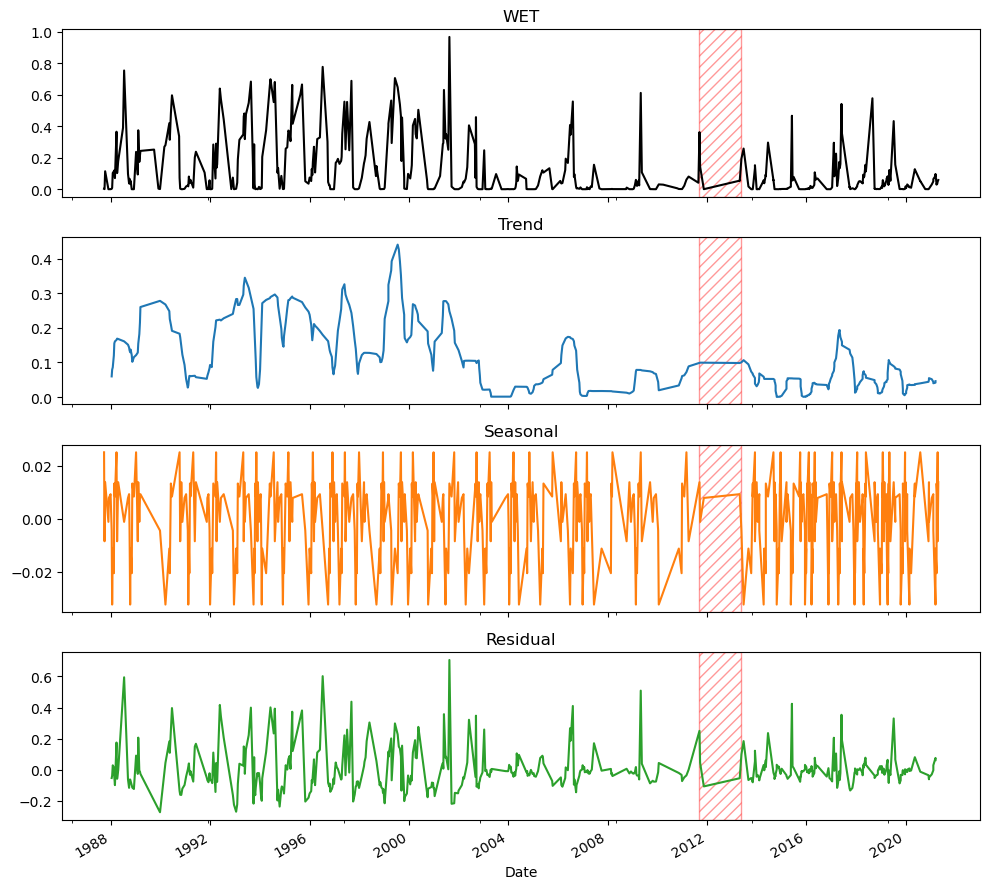

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime
from statsmodels.tsa.seasonal import seasonal_decompose

def generate_low_quality_data_periods(df):
    """
    This function generates low quality data periods, including the SLC off period
    (https://www.usgs.gov/faqs/what-landsat-7-etm-slc-data)
    and periods with an observation density of less than four observations within a
    twelve month (365 days) period.
    Off value is 100 where there is low data quality and 0 for good data.
    """
    df = df.copy()
    df.loc[:, "off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100

    return df

df = df.reset_index()
df["TIME"] = pd.to_datetime(df["TIME"])

# Generate low-quality data column
df = generate_low_quality_data_periods(df)

# Extract the variable
pv = df.set_index("TIME")["WET"].astype(float)

# Identify low-quality ranges based on off_value == 100
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    # Group consecutive low-quality periods
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Filter out large gaps for decomposition
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose the time series
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

# Plot
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="WET", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

# Shade low-quality data periods
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="red", hatch="///", alpha=0.4)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

Limitations
- The national bushfires layer did not include the major bushfire of 2003. Due to my lack of expertese in the area I would have analysed this at face value instead of realsing there was a issue with the underlying data. This meant I could not fully rely on the layer to be able to communicate the 'why'.

- 

Detected 28 abrupt change points in residuals.


NameError: name 'i' is not defined

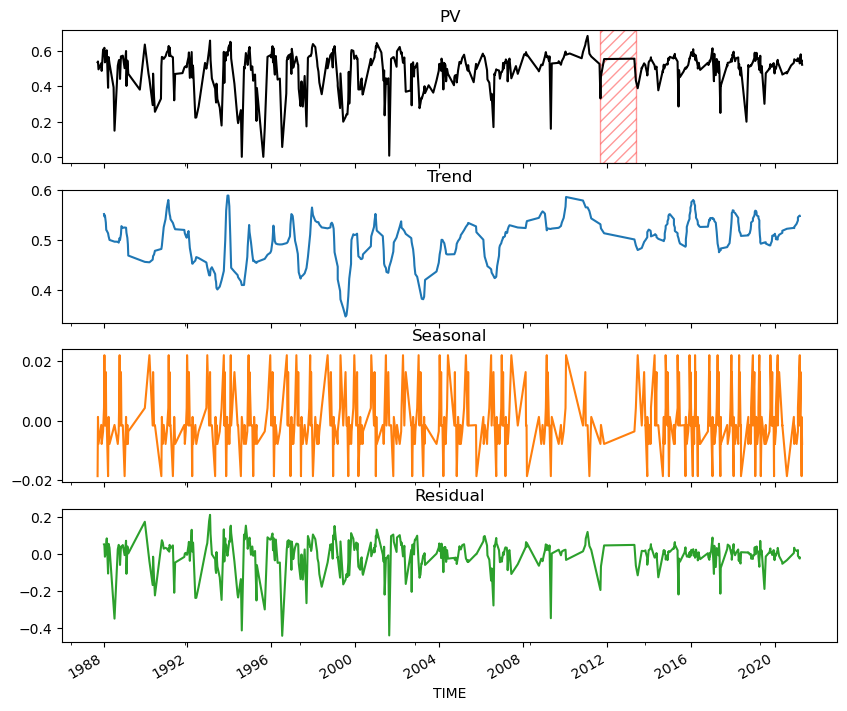

In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime


csv_path = "178.csv"                    #ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
df = pd.read_csv(csv_path)

# Convert date and sort
df["TIME"] = pd.to_datetime(df["TIME"])          # convert to datetime
df = df.sort_values("TIME").reset_index(drop=True)                       # set TIME as index

pv = df.resample('MS', on='TIME')["PV"].mean().interpolate(method='cubic')    #ACTION: Change the component you are analysing


# --- Function to generate low-quality data periods ---
def generate_low_quality_data_periods(df):
    """
    Generates low-quality data periods, including Landsat 7 SLC-off and
    periods with fewer than 4 observations within 365 days.
    Off value = 100 where low quality, 0 otherwise.
    """
    df = df.copy()
    df.loc[:, "off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100

    return df

# --- Assume df is loaded ---
df = df.reset_index(drop=True)
df["TIME"] = pd.to_datetime(df["TIME"])

# Generate low-quality data column
df = generate_low_quality_data_periods(df)

# Extract the variable of interest
pv = df.set_index("TIME")["PV"].astype(float)   # Change component here if needed

# Identify low-quality ranges
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Filter out large gaps for decomposition
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose the time series
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

# --- Detect abrupt changes in residuals ---
threshold = 2 * resid.std()   # 2 standard deviations from mean
change_points = resid[abs(resid) > threshold].index

print(f"Detected {len(change_points)} abrupt change points in residuals.")

# --- Plot ---
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="PV", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], title="Residual", color="tab:green")

# Shade low-quality data periods
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="red", hatch="///", alpha=0.4)
        

# Mark abrupt changes (orange dashed vertical lines)
for ax in axes:
    for cp in change_points:
        ax.axvline(cp, color="orange", linestyle="--", alpha=0.7)

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

Detected 28 abrupt change points in residuals.


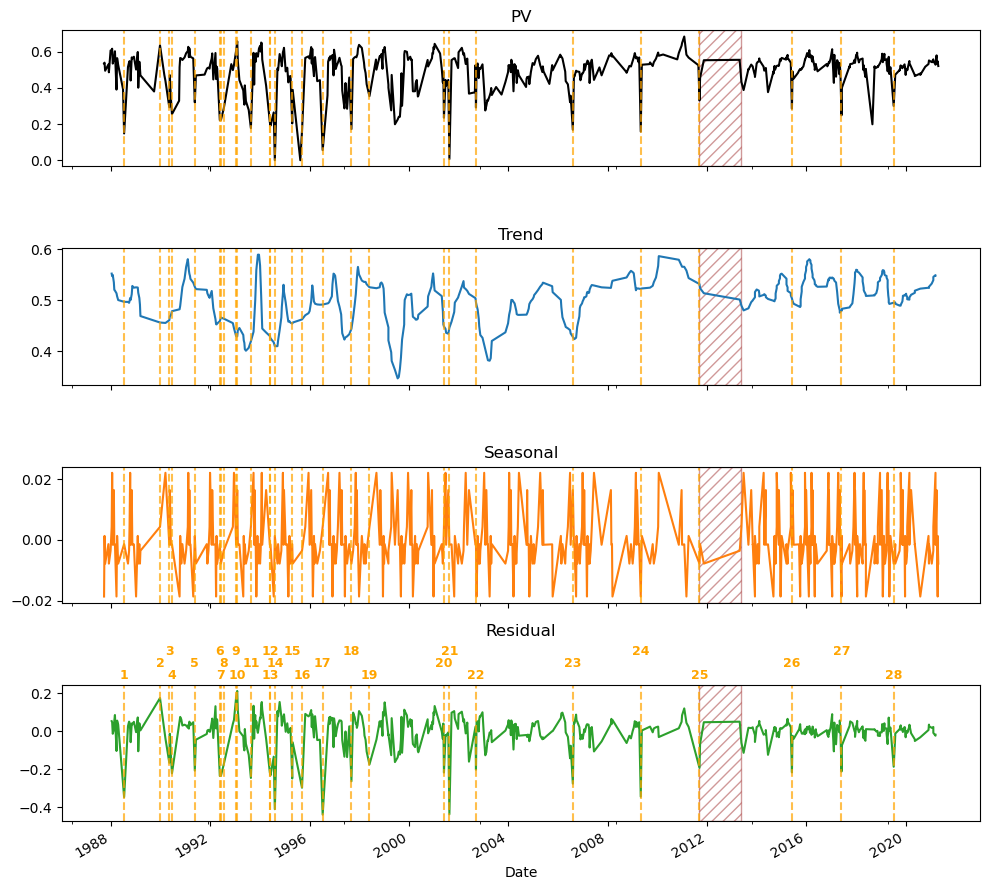

In [40]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import namedtuple
from matplotlib.dates import date2num
from statsmodels.tsa.seasonal import seasonal_decompose
import datetime
from scipy.stats import theilslopes
from collections import namedtuple


csv_path = "178.csv"                    #ACTION: Add CSV output form WIT tool - generates in .../DEA_products/...
df = pd.read_csv(csv_path)

# Convert date and sort
df["TIME"] = pd.to_datetime(df["TIME"])          # convert to datetime
df = df.sort_values("TIME").reset_index(drop=True)                       # set TIME as index

pv = df.resample('MS', on='TIME')["PV"].mean().interpolate(method='cubic')    #ACTION: Change the component you are analysing


# Function to generate low-quality data periods
def generate_low_quality_data_periods(df):
    """
    Generates low-quality data periods, including Landsat 7 SLC-off and
    periods with fewer than 4 observations within 365 days.
    Off value = 100 where low quality, 0 otherwise.
    """
    df = df.copy()
    df.loc[:, "off_value"] = 0

    # Landsat 5–8 SLC-off gap
    LS5_8_gap_start = datetime.datetime(2011, 11, 1)
    LS5_8_gap_end = datetime.datetime(2013, 4, 1)
    df.loc[
        (df["TIME"] >= LS5_8_gap_start) & (df["TIME"] <= LS5_8_gap_end),
        "off_value",
    ] = 100

    # Low observation density (less than 4 in 365 days)
    for i in range(3, len(df) - 3):
        if (df.loc[i + 3, "TIME"] - df.loc[i, "TIME"]).days > 365:
            df.loc[
                (df["TIME"] >= df.loc[i, "TIME"])
                & (df["TIME"] <= df.loc[i + 3, "TIME"]),
                "off_value",
            ] = 100

    return df

# Assume df is loaded
df = df.reset_index(drop=True)
df["TIME"] = pd.to_datetime(df["TIME"])

# Generate low-quality data column
df = generate_low_quality_data_periods(df)

# Extract the variable of interest
pv = df.set_index("TIME")["PV"].astype(float)   # Change component here if needed

# Identify low-quality ranges
low_quality_ranges = []
mask = df["off_value"] == 100
if mask.any():
    grouped = (mask != mask.shift()).cumsum()
    for _, group in df[mask].groupby(grouped):
        start, end = group["TIME"].iloc[0], group["TIME"].iloc[-1]
        low_quality_ranges.append((start, end))

# Filter out large gaps for decomposition
gaps = pv.index.to_series().diff().dt.days
pv_filtered = pv.loc[gaps.fillna(1) < 60]

# Decompose the time series
result = seasonal_decompose(pv_filtered, model="additive", period=12)
trend, seasonal, resid = result.trend, result.seasonal, result.resid

# Detect abrupt changes in residuals
threshold = 2 * resid.std()   # 2 standard deviations from mean
change_points = resid[abs(resid) > threshold].index

print(f"Detected {len(change_points)} abrupt change points in residuals.")

# Plot 
fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
pv.plot(ax=axes[0], title="PV", color="black")
trend.plot(ax=axes[1], title="Trend", color="tab:blue")
seasonal.plot(ax=axes[2], title="Seasonal", color="tab:orange")
resid.plot(ax=axes[3], color="tab:green")

# Adjust residual plot title placement
axes[3].set_title("Residual", pad=35)  # move title up to make space

# Shade low-quality data periods
for ax in axes:
    for start, end in low_quality_ranges:
        ax.axvspan(start, end, facecolor="none", edgecolor="darkred", hatch="///", alpha=0.4)

# Mark and number abrupt changes (orange dashed vertical lines)
change_points_sorted = sorted(change_points)
for idx, cp in enumerate(change_points_sorted, start=1):
    for ax in axes:
        ax.axvline(cp, color="orange", linestyle="--", alpha=0.7)
    
    # Alternate vertical positioning to prevent overlap (stagger up/down)
    mod = idx % 3
    if mod == 1:
        y_pos = resid.max() * 1.3  # lower label
    elif mod == 2:
        y_pos = resid.max() * 1.6  # middle label
    else:
        y_pos = resid.max() * 1.9  # upper label

    # Add label above the residual plot
    axes[3].text(
        cp,
        y_pos,
        str(idx),
        color="orange",
        fontsize=9,
        fontweight="bold",
        ha="center",
        rotation=0,
        clip_on=False, 
    )

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

In [27]:
resid.index.value_counts().head()

TIME
2021-04-24 23:50:18.000    1
1987-09-18 23:17:37.500    1
1987-09-25 23:23:58.000    1
1987-10-04 23:17:58.500    1
1987-11-21 23:18:53.500    1
Name: count, dtype: int64

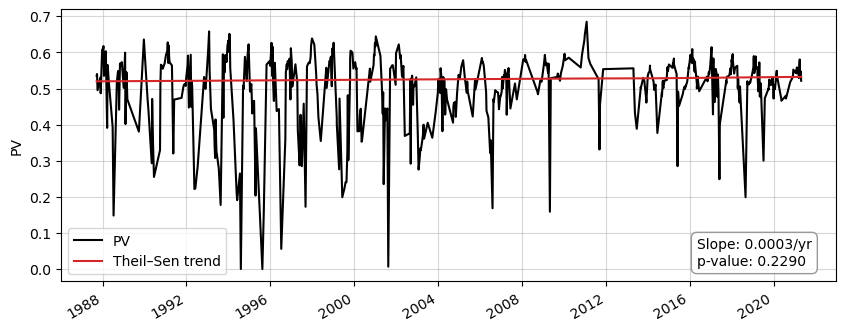

In [28]:
def mk_with_slopes(y, alpha=0.05):
    """
    Mann-Kendall test + Theil-Sen slope.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept'])
    
    # --- Mann-Kendall test ---
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    
    # --- Theil–Sen slope ---
    x_vals = np.arange(len(y))
    slope, intercept, _, _ = theilslopes(y, x_vals, 0.95)
    
    return res(p, slope, intercept)

# Run test
res = mk_with_slopes(pv)
p, slope, intercept = res.p, res.slope, res.intercept

# Plot
fig, ax = plt.subplots(figsize=(10, 4))

# Plot original data
pv.plot(ax=ax, label='PV', color='black')

# Generate fitted line using actual time order
x_vals = np.arange(len(pv))
trend_line = slope * x_vals + intercept
ax.plot(pv.index, trend_line, color='tab:red', label='Theil–Sen trend')

# Labels
ax.set_ylabel('PV')
ax.set_xlabel(None)
ax.grid(alpha=0.5)

# Annotation
textstr = f"Slope: {slope*12:.4f}/yr\np-value: {p:.4f}"
ax.text(
    0.82, 0.16, textstr,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.4", facecolor="white", edgecolor="gray", alpha=0.8)
)

ax.legend(loc='lower left')
plt.show()

In [29]:
print(f"First predicted value: {intercept:.2f}")
print(f"Last predicted value: {slope * len(pv) + intercept:.2f}")
print(f"Actual first value: {pv.iloc[0]:.2f}")
print(f"Actual last value: {pv.iloc[-1]:.2f}")

First predicted value: 0.52
Last predicted value: 0.53
Actual first value: 0.54
Actual last value: 0.52


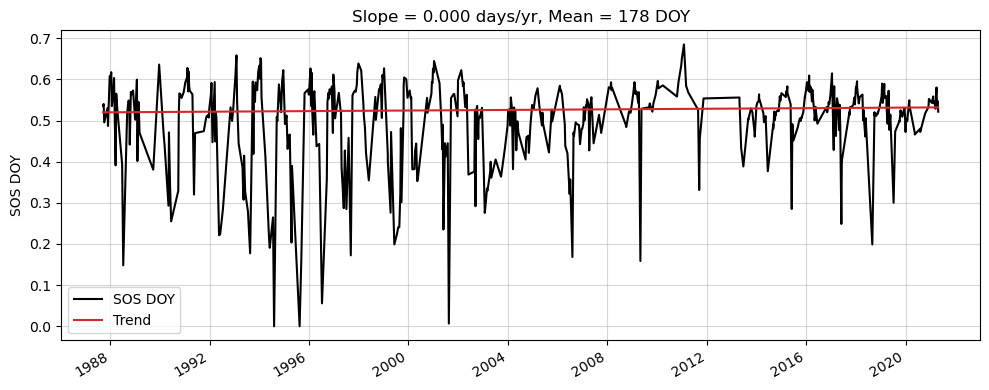

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import date2num
from scipy.stats import theilslopes
from collections import namedtuple

def mk_with_slopes(y, alpha=0.05):
    """
    Mann-Kendall test + Theil-Sen slope
    Returns slope in days/year and mean DOY.
    """
    res = namedtuple('Mann_Kendall_Test', ['p', 'slope', 'intercept', 'mean_doy'])
    
    # --- Mann-Kendall test ---
    x, c = __preprocessing(y)
    x, n = __missing_values_analysis(x, method='skip')
    s = __mk_score(x, n)
    var_s = __variance_s(x, n)
    z = __z_score(s, var_s)
    p, h, trend = __p_value(z, alpha)
    
    # --- Convert dates to numeric years ---
    years = np.array([d.year + (d.timetuple().tm_yday / 365.25) for d in y.index])
    
    # --- Theil–Sen slope in days/year ---
    slope, intercept, _, _ = theilslopes(y, years, 0.95)
    
    # --- Mean DOY ---
    mean_doy = np.mean(y.index.dayofyear)
    
    return res(p, slope, intercept, mean_doy)

# Run test
res = mk_with_slopes(pv)
p, slope, intercept, mean_doy = res

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
pv.plot(ax=ax, label='SOS DOY', color='black')

# Generate fitted line
years = np.array([d.year + (d.timetuple().tm_yday / 365.25) for d in pv.index])
trend_line = slope * years + intercept
ax.plot(pv.index, trend_line, color='tab:red', label='Trend')

# Titles and labels
ax.set_ylabel("SOS DOY")
ax.set_xlabel(None)
ax.grid(alpha=0.5)

# Title with slope and mean DOY
ax.set_title(f"Slope = {slope:.3f} days/yr, Mean = {mean_doy:.0f} DOY")

ax.legend(loc='lower left')
plt.tight_layout()
plt.show()

In [39]:
from datacube.utils.geometry import Geometry, CRS 

polygon_path = "ginini_flats.shp"   #ACTION: change this if your polygon file has another name
poly = gpd.read_file(polygon_path)

# Ensure CRS is defined (use the same projection as WIT)
if poly.crs is None:
    poly = poly.set_crs("EPSG:3577")  # or EPSG:4326 if your polygon is in lat/long

# Convert to datacube geometry
gpgon = Geometry(poly.geometry[0], CRS(str(poly.crs)))

NameError: name 'change_df' is not defined

In [38]:
# Parameters
change_id_to_validate = 3   # ACTION: Change this number to select which change to validate based on the ID in both the graph and table
time_window_days = 15       # ACTION: How many days before/after to search for images

# Locate the change event
selected_change = change_df.loc[change_df["ID"] == change_id_to_validate]

if selected_change.empty:
    raise ValueError(f"No change found with ID {change_id_to_validate}")

change_date = selected_change["Date"].values[0]
change_date = pd.to_datetime(change_date)

# Define time range (before and after change)
time_before = (change_date - timedelta(days=time_window_days)).strftime("%Y-%m-%d")
time_after  = (change_date + timedelta(days=time_window_days)).strftime("%Y-%m-%d")

# Load satellite data around the change date
bands = [f"nbart_{band}" for band in ("blue", "green", "red", "nir", "swir_1", "swir_2")]

dc = Datacube(app="change_validation")

ds = load_ard(
    dc,
    products=["ga_ls8c_ard_3", "ga_ls7e_ard_3", "ga_ls5t_ard_3"],
    ls7_slc_off=False,
    measurements=bands,
    geopolygon=gpgon,
    output_crs="EPSG:3577",
    resolution=(-30, 30),
    resampling={"fmask": "nearest", "*": "bilinear"},
    time=(time_before, time_after),
    group_by="solar_day",
    dask_chunks={"time": 1, "x": 2048, "y": 2048},
)

# Load into memory
ds.load()

# Define output folder
out_folder = "validation_images"
os.makedirs(out_folder, exist_ok=True)

# Identify nearest pre- and post-change images
time_values = ds.time.values
closest_pre_idx = (np.abs(time_values - np.datetime64(change_date - timedelta(days=1)))).argmin()
closest_post_idx = (np.abs(time_values - np.datetime64(change_date + timedelta(days=1)))).argmin()

# Select datasets
pre_ds = ds.isel(time=closest_pre_idx)
post_ds = ds.isel(time=closest_post_idx)

# Save images
pre_path = os.path.join(out_folder, f"change_{change_id_to_validate}_before.tif")
post_path = os.path.join(out_folder, f"change_{change_id_to_validate}_after.tif")

pre_ds.to_netcdf(pre_path)
post_ds.to_netcdf(post_path)

print(f"✅ Saved validation images for Change ID {change_id_to_validate}")
print(f"Before: {pre_path}")
print(f"After:  {post_path}")

NameError: name 'change_df' is not defined